In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
cephasax_obdii_ds3_path = kagglehub.dataset_download('cephasax/obdii-ds3')

print('Data source import complete.')


100%|██████████| 7.39M/7.39M [00:00<00:00, 121MB/s]

Extracting files...


Data source import complete.


In [2]:
cephasax_obdii_ds3_path

'/root/.cache/kagglehub/datasets/cephasax/obdii-ds3/versions/3'

In [4]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, f1_score, accuracy_score

# Suppress TF warnings for clean output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. Configuration & Data Loading ---
DATA_PATH = '/root/.cache/kagglehub/datasets/cephasax/obdii-ds3/versions/3/exp1_14drivers_14cars_dailyRoutes.csv'
TIME_STEPS = 5
GAP_THRESHOLD_MS = 60000

print("--- 1. Loading and Cleaning Data ---")
df = pd.read_csv(DATA_PATH, low_memory=False)

def clean_currency_fmt(x):
    if pd.isna(x): return np.nan
    if isinstance(x, str): x = x.replace('%', '').replace(',', '.')
    try: return float(x)
    except ValueError: return np.nan

for col in ['ENGINE_RPM', 'SPEED', 'ENGINE_COOLANT_TEMP']:
    df[col] = df[col].apply(clean_currency_fmt)

def create_binary_target(code):
    if pd.isna(code): return "Normal"
    code = str(code).strip()
    if code == "nan": return "Normal"
    clean_code = code[:5]
    if clean_code in ['P0133', 'C0300']: return "Fault"
    elif clean_code == "Normal": return "Normal"
    else: return "Drop"

df['Target'] = df['TROUBLE_CODES'].apply(create_binary_target)
df = df[df['Target'] != 'Drop'].copy()

df['Ratio_RPM_Speed'] = df['ENGINE_RPM'] / (df['SPEED'] + 1)
df['Thermal_Stress'] = df['ENGINE_RPM'] * df['ENGINE_COOLANT_TEMP']
df['Is_Idle'] = (df['SPEED'] < 1).astype(int)
df['Oil_Pressure_PSI'] = 30.0

feature_cols = [
    'ENGINE_RPM', 'SPEED', 'ENGINE_COOLANT_TEMP',
    'Oil_Pressure_PSI', 'Ratio_RPM_Speed', 'Thermal_Stress', 'Is_Idle'
]

# Ensure crucial sequence columns are present
df = df.dropna(subset=feature_cols + ['VEHICLE_ID', 'TIMESTAMP'])

le = LabelEncoder()
df['Target_Encoded'] = le.fit_transform(df['Target'])


# --- 2. Advanced Sequence Engineering (Trip Isolation) ---
print("\n--- 2. Building Safe Time-Series Sequences ---")
df = df.sort_values(by=['VEHICLE_ID', 'TIMESTAMP'])

# Calculate time difference to isolate trips
df['Time_Diff'] = df.groupby('VEHICLE_ID')['TIMESTAMP'].diff()
# A new trip starts if the gap is larger than our threshold, or if it's the first record (NaN)
df['New_Trip'] = (df['Time_Diff'] > GAP_THRESHOLD_MS) | df['Time_Diff'].isna()
df['Trip_ID'] = df['New_Trip'].cumsum()

print(f"Total isolated trips identified: {df['Trip_ID'].nunique()}")

def create_safe_sequences(df, feature_cols, target_col, time_steps):
    Xs, ys = [], []
    for _, group in df.groupby('Trip_ID'):
        if len(group) <= time_steps:
            continue

        group_X = group[feature_cols].values
        group_y = group[target_col].values

        for i in range(len(group) - time_steps):
            Xs.append(group_X[i:(i + time_steps)])
            ys.append(group_y[i + time_steps])

    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_safe_sequences(df, feature_cols, 'Target_Encoded', TIME_STEPS)
print(f"Generated Sequence Matrix Shape: {X_seq.shape}")


# --- 3. Splitting and Scaling ---
print("\n--- 3. Preprocessing Sequences ---")
# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

scaler = StandardScaler()
# Scale 3D data by reshaping to 2D first
X_train_2d = X_train.reshape(-1, len(feature_cols))
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_train_scaled = X_train_scaled_2d.reshape(X_train.shape[0], TIME_STEPS, len(feature_cols))

X_test_2d = X_test.reshape(-1, len(feature_cols))
X_test_scaled_2d = scaler.transform(X_test_2d)
X_test_scaled = X_test_scaled_2d.reshape(X_test.shape[0], TIME_STEPS, len(feature_cols))


# --- 4. LSTM Model Architecture & Training ---
print("\n--- 4. Training LSTM Model ---")
model = Sequential([
    LSTM(64, activation='relu', input_shape=(TIME_STEPS, len(feature_cols)), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Binary output
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


# --- 5. Evaluation & Comparison ---
print("\n--- 5. Final Evaluation ---")
# Convert probabilities to binary classes
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("\nDetailed Report [LSTM Model]:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

rf_accuracy = 0.88 # From our previous benchmark
lstm_accuracy = accuracy_score(y_test, y_pred)

print(f"\n--- Benchmark Summary ---")
print(f"Random Forest Accuracy (Previous): {rf_accuracy:.4f}")
print(f"LSTM Sequence Accuracy (Current):  {lstm_accuracy:.4f}")

if lstm_accuracy > rf_accuracy:
    print("Conclusion: LSTM outperformed Random Forest by leveraging temporal patterns.")
else:
    print("Conclusion: Random Forest outperformed LSTM. Tabular snapshot is sufficient for these specific features.")

--- 1. Loading and Cleaning Data ---

--- 2. Building Safe Time-Series Sequences ---
Total isolated trips identified: 300
Generated Sequence Matrix Shape: (31241, 5, 7)

--- 3. Preprocessing Sequences ---

--- 4. Training LSTM Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7965 - loss: 0.4516 - val_accuracy: 0.8828 - val_loss: 0.2903
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8820 - loss: 0.2898 - val_accuracy: 0.8854 - val_loss: 0.2736
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8871 - loss: 0.2803 - val_accuracy: 0.8936 - val_loss: 0.2551
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8904 - loss: 0.2672 - val_accuracy: 0.8970 - val_loss: 0.2438
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8926 - loss: 0.2544 - val_accuracy: 0.9024 - val_loss: 0.2378
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8940 - loss: 0.2477 - val_accuracy: 0.8980 - val_loss: 0.2275
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8988 - loss: 0.2369 - val_accuracy: 0.9062 - val_loss: 0.2224
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9032 - loss: 0.2286 - val_accuracy: 0.

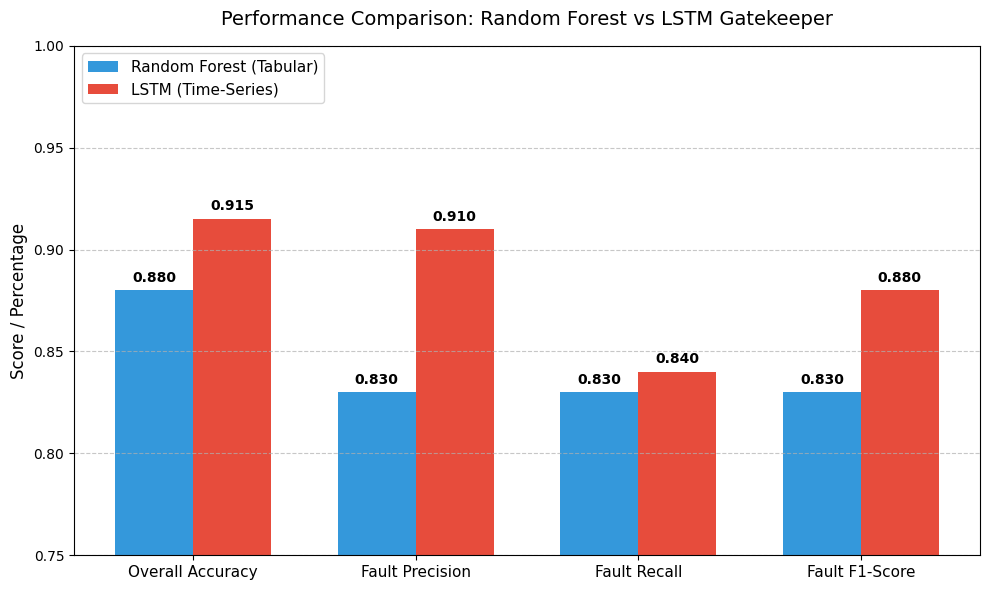

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Define metrics and hardcoded scores from previous evaluations
metrics = ['Overall Accuracy', 'Fault Precision', 'Fault Recall', 'Fault F1-Score']
rf_scores = [0.880, 0.830, 0.830, 0.830]
lstm_scores = [0.915, 0.910, 0.840, 0.880]

x = np.arange(len(metrics))
width = 0.35

# Setup plot style
plt.figure(figsize=(10, 6))
ax = plt.subplot(111)

# Create bars
rects1 = ax.bar(x - width/2, rf_scores, width, label='Random Forest (Tabular)', color='#3498db')
rects2 = ax.bar(x + width/2, lstm_scores, width, label='LSTM (Time-Series)', color='#e74c3c')

# Customize axes and labels
ax.set_ylabel('Score / Percentage', fontsize=12)
ax.set_title('Performance Comparison: Random Forest vs LSTM Gatekeeper', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim([0.75, 1.0])

# Add grid for readability
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(loc='upper left', fontsize=11)

# Function to auto-label bar heights
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
# Uncomment the line below to save the figure locally
# plt.savefig('rf_vs_lstm_comparison.png', dpi=300)
plt.show()